***QUESTION 2***: _How did housing price indices in affected regions change before and after Hurricane Katrina, and is there statistically significant evidence of a structural shift in housing prices following the event?_


In [4]:
import pandas as pd

hpi_state = pd.read_csv("hpi_at_state.csv", header=None)
print(hpi_state.head(10))
print(hpi_state.shape)

    0     1  2      3
0  AK  1975  1  61.64
1  AK  1975  2  63.79
2  AK  1975  3  67.48
3  AK  1975  4  68.76
4  AK  1976  1  70.46
5  AK  1976  2  69.84
6  AK  1976  3  74.89
7  AK  1976  4  72.30
8  AK  1977  1  78.83
9  AK  1977  2  79.63
(10149, 4)


**Cell 1**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

**Cell 2**

In [19]:
hpi_state = pd.read_csv("hpi_at_state.csv", header=None)

hpi_state.columns = ['state', 'year', 'quarter', 'hpi']

print("Shape:", hpi_state.shape)
print("\nColumns:", hpi_state.columns.tolist())
print("\nFirst 10 rows:")
print(hpi_state.head(10))

Shape: (10149, 4)

Columns: ['state', 'year', 'quarter', 'hpi']

First 10 rows:
  state  year  quarter    hpi
0    AK  1975        1  61.64
1    AK  1975        2  63.79
2    AK  1975        3  67.48
3    AK  1975        4  68.76
4    AK  1976        1  70.46
5    AK  1976        2  69.84
6    AK  1976        3  74.89
7    AK  1976        4  72.30
8    AK  1977        1  78.83
9    AK  1977        2  79.63


**Cell 3**

In [20]:
hpi_state['year'] = pd.to_numeric(hpi_state['year'], errors='coerce')
hpi_state['quarter'] = pd.to_numeric(hpi_state['quarter'], errors='coerce')
hpi_state['hpi'] = pd.to_numeric(hpi_state['hpi'], errors='coerce')

hpi_state = hpi_state.dropna()

print(hpi_state.dtypes)
print("\nNumber of states:", hpi_state['state'].nunique())
print("Years covered:", hpi_state['year'].min(), "to", hpi_state['year'].max())

state          str
year         int64
quarter      int64
hpi        float64
dtype: object

Number of states: 51
Years covered: 1975 to 2024


**Cell 4**

In [21]:
gulf_states = ['LA', 'MS', 'AL']
hpi_gulf = hpi_state[hpi_state['state'].isin(gulf_states)].copy()

print(hpi_gulf['state'].value_counts())
hpi_gulf.head()

state
AL    199
LA    199
MS    199
Name: count, dtype: int64


,state,year,quarter,hpi
199,AL,1975,1,75.11
200,AL,1975,2,72.11
201,AL,1975,3,74.51
202,AL,1975,4,71.44
203,AL,1976,1,76.92


**Cell 5**

In [22]:
annual_hpi = (
    hpi_gulf.groupby(['state', 'year'], as_index=False)['hpi']
    .mean()
    .sort_values(['state', 'year'])
)

print(annual_hpi.head(15))

   state  year       hpi
0     AL  1975   73.2925
1     AL  1976   76.8775
2     AL  1977   85.4650
3     AL  1978   92.4500
4     AL  1979  102.1025
5     AL  1980  105.3725
6     AL  1981  108.1275
7     AL  1982  109.6625
8     AL  1983  114.8250
9     AL  1984  122.2275
10    AL  1985  125.1675
11    AL  1986  132.4525
12    AL  1987  138.5825
13    AL  1988  142.0425
14    AL  1989  144.0150


**Cell 6**

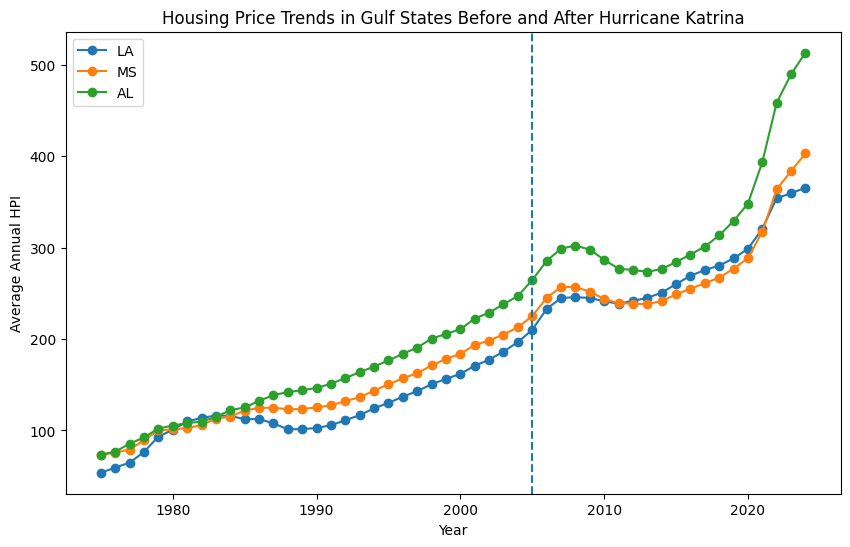

In [10]:
plt.figure(figsize=(10, 6))

for state in gulf_states:
    state_data = annual_hpi[annual_hpi['state'] == state]
    plt.plot(state_data['year'], state_data['hpi'], marker='o', label=state)

plt.axvline(x=2005, linestyle='--')
plt.xlabel("Year")
plt.ylabel("Average Annual HPI")
plt.title("Housing Price Trends in Gulf States Before and After Hurricane Katrina")
plt.legend()
plt.show()

**Cell 7**

In [11]:
la_hpi = annual_hpi[annual_hpi['state'] == 'LA'].copy()

print(la_hpi.head(10))
print("\nLouisiana years covered:", la_hpi['year'].min(), "to", la_hpi['year'].max())

   state  year       hpi
50    LA  1975   53.7800
51    LA  1976   59.3825
52    LA  1977   64.8225
53    LA  1978   76.5400
54    LA  1979   93.3375
55    LA  1980  100.7575
56    LA  1981  109.8275
57    LA  1982  113.7475
58    LA  1983  116.3275
59    LA  1984  116.0825

Louisiana years covered: 1975 to 2024


**Cell 8**

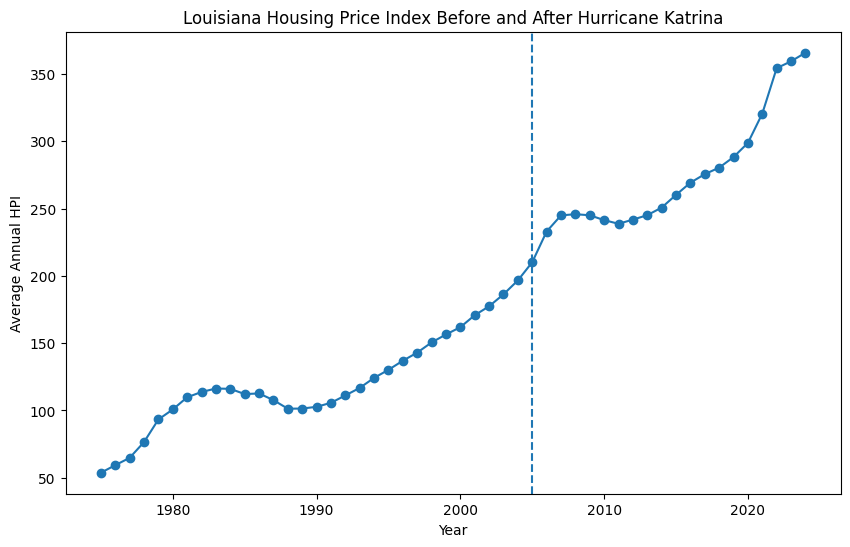

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(la_hpi['year'], la_hpi['hpi'], marker='o')
plt.axvline(x=2005, linestyle='--')
plt.xlabel("Year")
plt.ylabel("Average Annual HPI")
plt.title("Louisiana Housing Price Index Before and After Hurricane Katrina")
plt.show()

**Cell 9**

In [13]:
la_pre = la_hpi[la_hpi['year'] < 2005]['hpi']
la_post = la_hpi[la_hpi['year'] > 2005]['hpi']

print("Number of pre-Katrina annual observations:", len(la_pre))
print("Number of post-Katrina annual observations:", len(la_post))

print("\nPre-Katrina mean HPI:", la_pre.mean())
print("Post-Katrina mean HPI:", la_post.mean())

Number of pre-Katrina annual observations: 30
Number of post-Katrina annual observations: 19

Pre-Katrina mean HPI: 120.35150000000002
Post-Katrina mean HPI: 276.7384649122807


**Cell 10**

In [14]:
la_ttest = ttest_ind(la_pre, la_post, equal_var=False)

print("LOUISIANA PRE VS POST KATRINA T-TEST")
print("T-statistic:", la_ttest.statistic)
print("P-value:", la_ttest.pvalue)

LOUISIANA PRE VS POST KATRINA T-TEST
T-statistic: -13.116104330182335
P-value: 1.3078713297458143e-14


**Cell 11**

In [15]:
results = []

for state in gulf_states:
    state_data = annual_hpi[annual_hpi['state'] == state]
    pre = state_data[state_data['year'] < 2005]['hpi']
    post = state_data[state_data['year'] > 2005]['hpi']
    
    test = ttest_ind(pre, post, equal_var=False)
    
    results.append({
        'state': state,
        'pre_mean_hpi': pre.mean(),
        'post_mean_hpi': post.mean(),
        'difference_post_minus_pre': post.mean() - pre.mean(),
        't_statistic': test.statistic,
        'p_value': test.pvalue
    })

results_df = pd.DataFrame(results)
print(results_df)

  state  pre_mean_hpi  post_mean_hpi  difference_post_minus_pre  t_statistic  \
0    LA    120.351500     276.738465                 156.386965   -13.116104   
1    MS    135.047833     277.802632                 142.754798   -10.379686   
2    AL    152.191083     331.436053                 179.244969    -9.156556   

        p_value  
0  1.307871e-14  
1  1.317878e-11  
2  6.737215e-10  


**Cell 12**

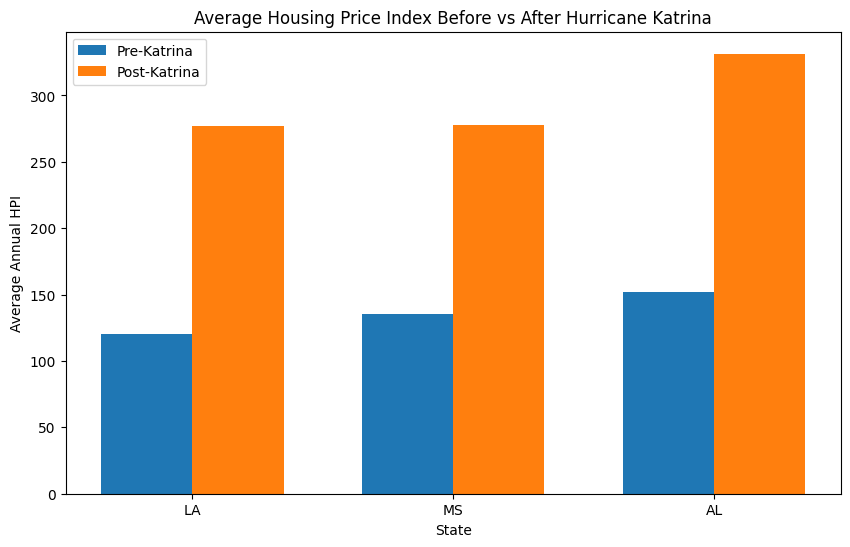

In [16]:
x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, results_df['pre_mean_hpi'], width, label='Pre-Katrina')
plt.bar(x + width/2, results_df['post_mean_hpi'], width, label='Post-Katrina')

plt.xticks(x, results_df['state'])
plt.xlabel("State")
plt.ylabel("Average Annual HPI")
plt.title("Average Housing Price Index Before vs After Hurricane Katrina")
plt.legend()
plt.show()

**Cell 13**

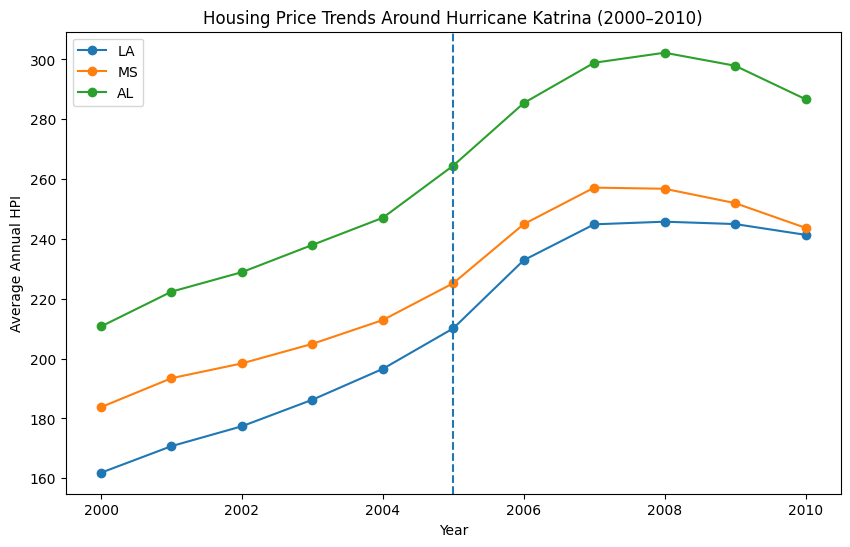

In [17]:
annual_zoom = annual_hpi[(annual_hpi['year'] >= 2000) & (annual_hpi['year'] <= 2010)]

plt.figure(figsize=(10, 6))

for state in gulf_states:
    state_data = annual_zoom[annual_zoom['state'] == state]
    plt.plot(state_data['year'], state_data['hpi'], marker='o', label=state)

plt.axvline(x=2005, linestyle='--')
plt.xlabel("Year")
plt.ylabel("Average Annual HPI")
plt.title("Housing Price Trends Around Hurricane Katrina (2000–2010)")
plt.legend()
plt.show()

**New Cell Call**

In [23]:
# SHORT-TERM EFFECT: compare 3 years before vs 3 years after Katrina

la_short_pre = la_hpi[(la_hpi['year'] >= 2002) & (la_hpi['year'] < 2005)]['hpi']
la_short_post = la_hpi[(la_hpi['year'] > 2005) & (la_hpi['year'] <= 2008)]['hpi']

print("Short-term pre mean:", la_short_pre.mean())
print("Short-term post mean:", la_short_post.mean())

short_test = ttest_ind(la_short_pre, la_short_post, equal_var=False)

print("\nSHORT-TERM T-TEST")
print("T-stat:", short_test.statistic)
print("P-value:", short_test.pvalue)

Short-term pre mean: 186.75583333333336
Short-term post mean: 241.20083333333332

SHORT-TERM T-TEST
T-stat: -7.8618106172739965
P-value: 0.0019278685400351597
